# COMI Comparison Training Notebook

This notebook runs the full model comparison in the required order:

1. Random Forest + PCA
2. Baseline CNN
3. ResNet18

Then it saves shared evaluation outputs and a final comparison table.

In [1]:
from pathlib import Path

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Google Colab drive mount skipped. Update the paths manually if needed.')

PROJECT_ROOT = Path('/content/drive/MyDrive/494_Project_test_3/comi_comparison_project')
DATASET_ROOT = Path('/content/drive/MyDrive/494_Project_test_3/COMI/dataset/BPAEC')
RESULTS_ROOT = PROJECT_ROOT / 'results'
FIGURES_ROOT = RESULTS_ROOT / 'figures'

print('PROJECT_ROOT =', PROJECT_ROOT)
print('DATASET_ROOT =', DATASET_ROOT)
print('RESULTS_ROOT =', RESULTS_ROOT)

Mounted at /content/drive
PROJECT_ROOT = /content/drive/MyDrive/494_Project_test_3/comi_comparison_project
DATASET_ROOT = /content/drive/MyDrive/494_Project_test_3/COMI/dataset/BPAEC
RESULTS_ROOT = /content/drive/MyDrive/494_Project_test_3/comi_comparison_project/results


In [2]:
import subprocess
import sys

subprocess.check_call([
    sys.executable,
    '-m',
    'pip',
    'install',
    '-q',
    '-r',
    str(PROJECT_ROOT / 'requirements_colab.txt'),
])

sys.path.insert(0, str(PROJECT_ROOT / 'src'))

In [3]:
import pandas as pd
import torch
from IPython.display import display

from comi_pipeline import (
    CLASS_NAMES,
    RFConfig,
    TrainingConfig,
    build_model,
    build_model_richness_table,
    build_split_manifest,
    compare_model_metrics,
    create_dataloaders,
    ensure_dir,
    evaluate_and_save,
    evaluate_random_forest_and_save,
    fit_model,
    plot_class_distribution,
    plot_confidence_histogram,
    plot_confusion_matrix,
    plot_model_comparison_chart,
    plot_prediction_examples,
    plot_sample_images,
    plot_training_history,
    prepare_rf_data,
    resolve_device,
    save_manifest,
    seed_everything,
    summarize_manifest,
    train_random_forest,
)

seed_everything(42)
device = resolve_device()
ensure_dir(RESULTS_ROOT)
ensure_dir(FIGURES_ROOT)
print('Using device:', device)
print('CUDA available:', torch.cuda.is_available())

Using device: cuda
CUDA available: True


split,test,train,val,total
actin,100,500,100,700
mitochondria,97,485,97,679
nucleus,100,500,100,700
total,297,1485,297,2079


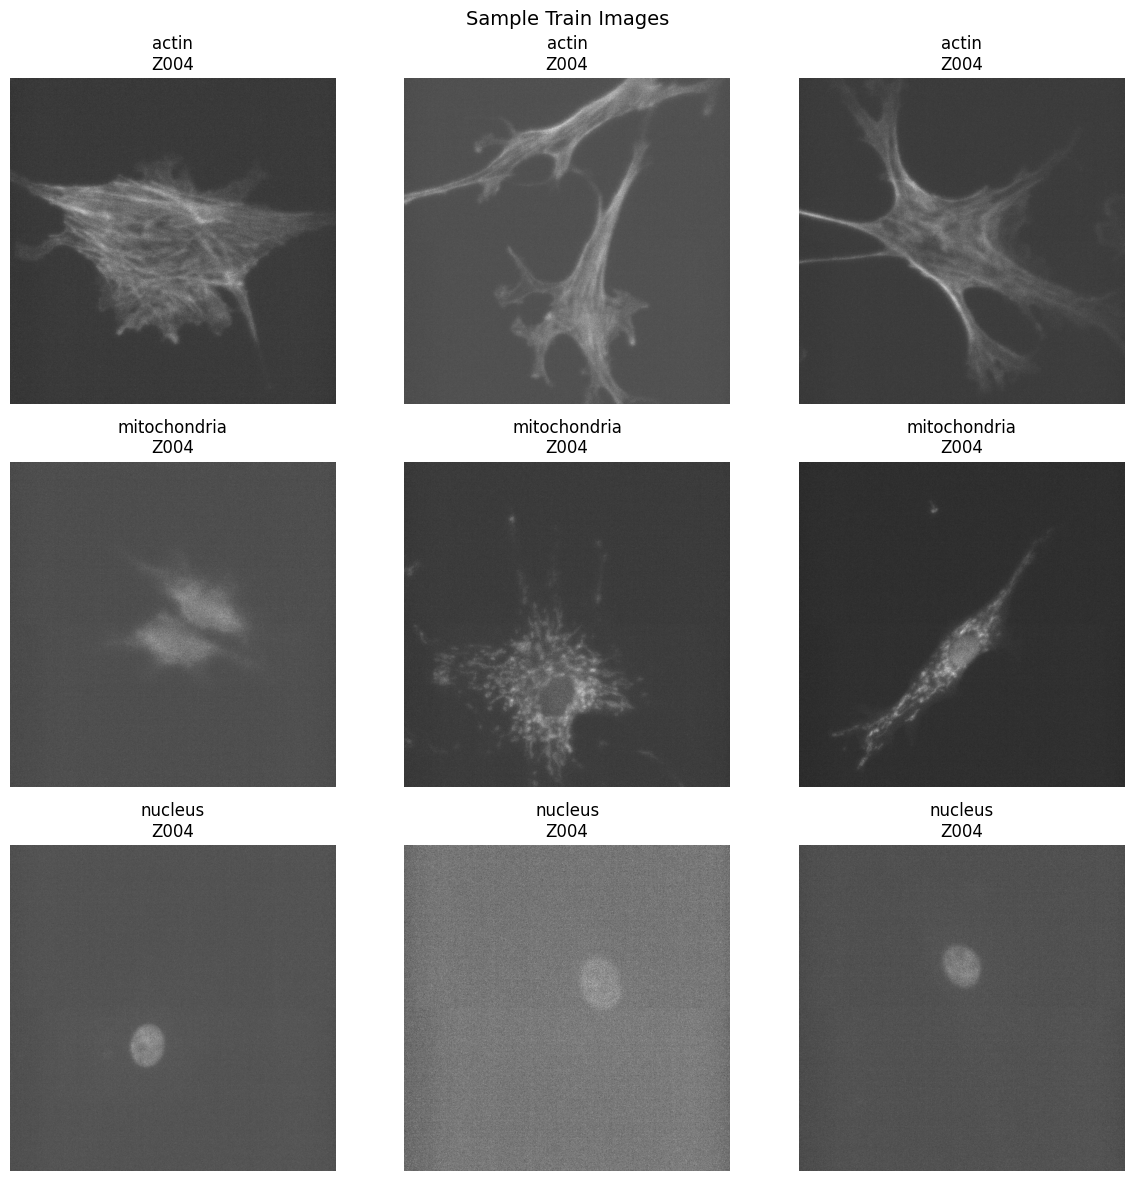

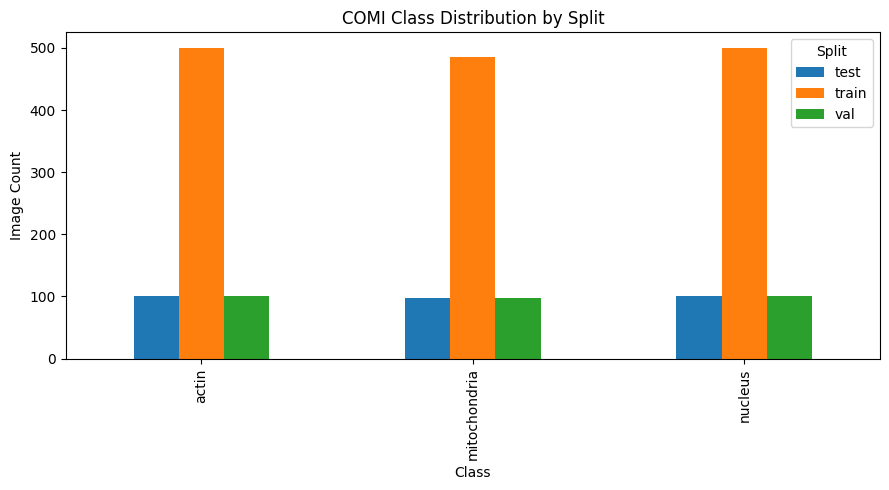

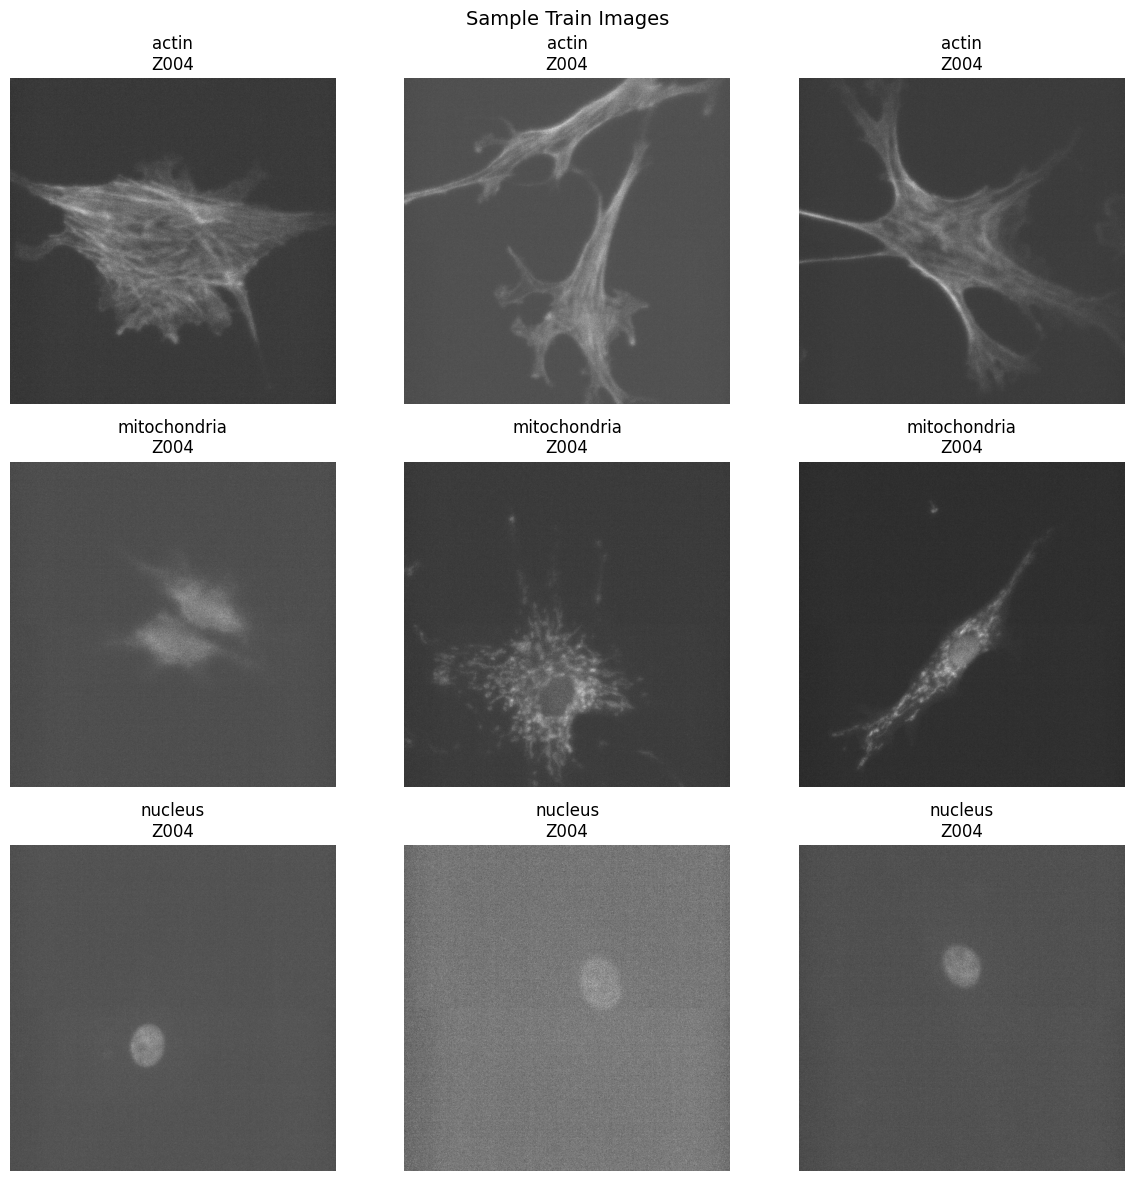

In [4]:
manifest = build_split_manifest(DATASET_ROOT)
summary = summarize_manifest(manifest)
save_manifest(manifest, RESULTS_ROOT / 'comi_split_manifest.csv')
summary.to_csv(RESULTS_ROOT / 'comi_split_summary.csv')
display(summary)
plot_class_distribution(manifest, FIGURES_ROOT / 'class_distribution.png')
plot_sample_images(manifest, samples_per_class=3, split='train', output_path=FIGURES_ROOT / 'sample_train_images.png')

In [5]:
RUN_SMOKE_TEST = False

if RUN_SMOKE_TEST:
    smoke_manifest = manifest.groupby(['split', 'class_name'], group_keys=False).head(12).reset_index(drop=True)
    smoke_rf_config = RFConfig(image_size=64, n_estimators=50)
    smoke_rf_data = prepare_rf_data(smoke_manifest, smoke_rf_config)
    smoke_rf_model = train_random_forest(smoke_rf_data, smoke_rf_config, RESULTS_ROOT / 'smoke_rf')
    smoke_rf_predictions, smoke_rf_metrics, _ = evaluate_random_forest_and_save(smoke_rf_model, smoke_rf_data, RESULTS_ROOT / 'smoke_rf')
    display(pd.DataFrame([smoke_rf_metrics]).drop(columns=['confusion_matrix', 'classification_report']))

    smoke_cnn_loaders, _, _ = create_dataloaders(smoke_manifest, image_size=224, batch_size=16, num_workers=2, normalize_mode='simple')
    smoke_cnn_config = TrainingConfig(model_name='baseline_cnn', batch_size=16, num_epochs=2, early_stopping_patience=2, normalize_mode='simple')
    smoke_cnn_model = build_model('baseline_cnn', num_classes=len(CLASS_NAMES), pretrained=False)
    smoke_cnn_model, smoke_cnn_history = fit_model(smoke_cnn_model, smoke_cnn_loaders, smoke_cnn_config, RESULTS_ROOT / 'smoke_cnn', device=device, pretrained=False)
    display(smoke_cnn_history)

    smoke_resnet_loaders, _, _ = create_dataloaders(smoke_manifest, image_size=224, batch_size=16, num_workers=2, normalize_mode='imagenet')
    smoke_resnet_config = TrainingConfig(model_name='resnet18', batch_size=16, num_epochs=2, early_stopping_patience=2, normalize_mode='imagenet')
    smoke_resnet_model = build_model('resnet18', num_classes=len(CLASS_NAMES), pretrained=True)
    smoke_resnet_model, smoke_resnet_history = fit_model(smoke_resnet_model, smoke_resnet_loaders, smoke_resnet_config, RESULTS_ROOT / 'smoke_resnet', device=device, pretrained=True)
    display(smoke_resnet_history)
else:
    print('Smoke test skipped. Set RUN_SMOKE_TEST = True only when you want a fast end-to-end sanity check.')

Smoke test skipped. Set RUN_SMOKE_TEST = True only when you want a fast end-to-end sanity check.


## 1. Random Forest + PCA

,accuracy,precision_macro,recall_macro,f1_macro
0,0.959596,0.959363,0.959485,0.959279


,precision,recall,f1-score,support
actin,0.958763,0.930000,0.944162,100.000000
mitochondria,0.948454,0.948454,0.948454,97.000000
nucleus,0.970874,1.000000,0.985222,100.000000
accuracy,0.959596,0.959596,0.959596,0.959596
macro avg,0.959363,0.959485,0.959279,297.000000
weighted avg,0.959474,0.959596,0.959389,297.000000


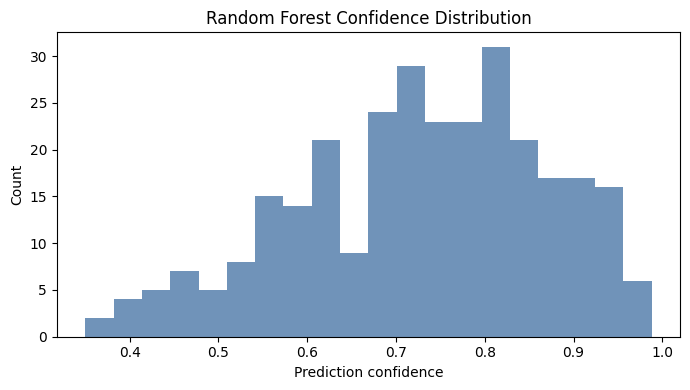

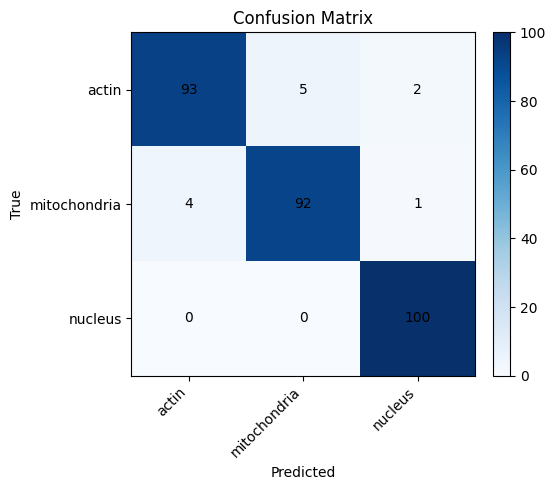

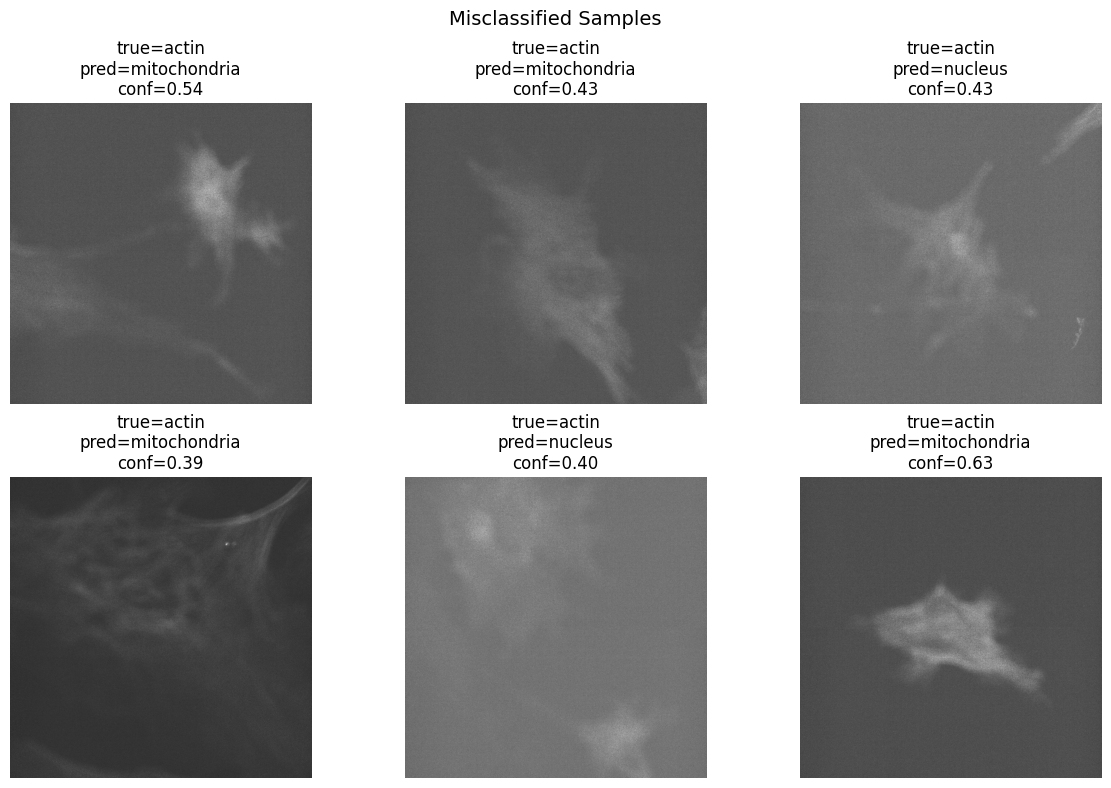

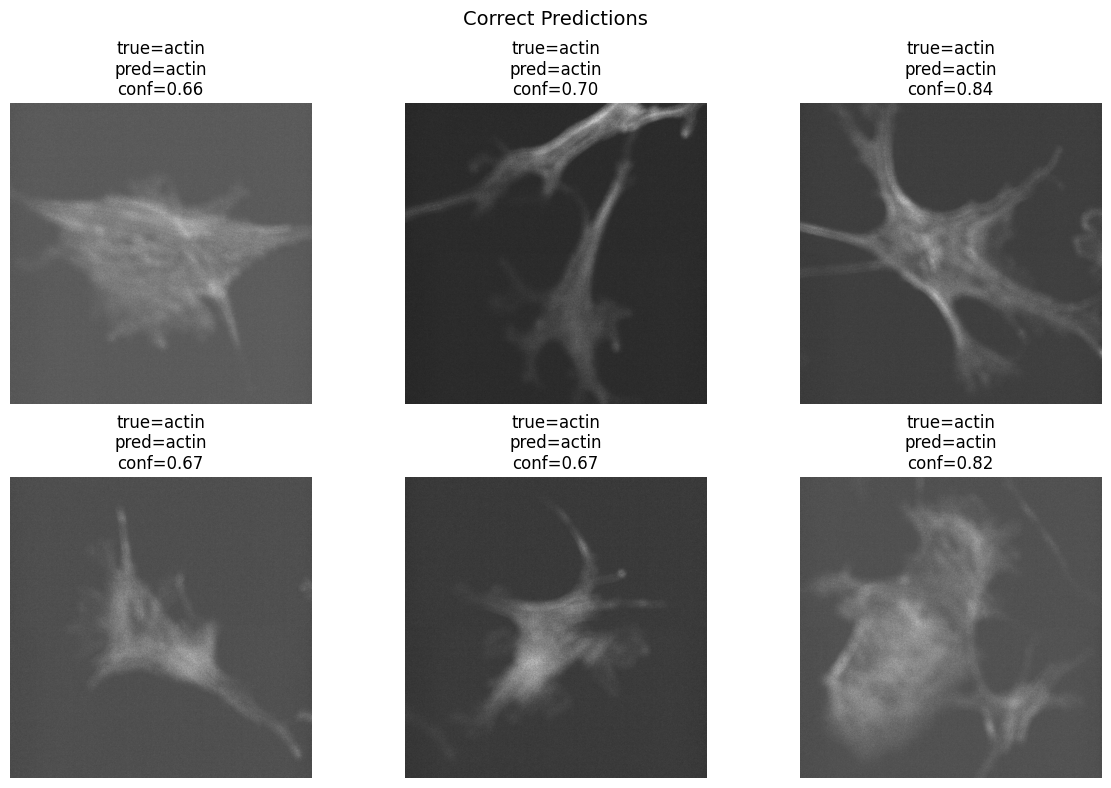

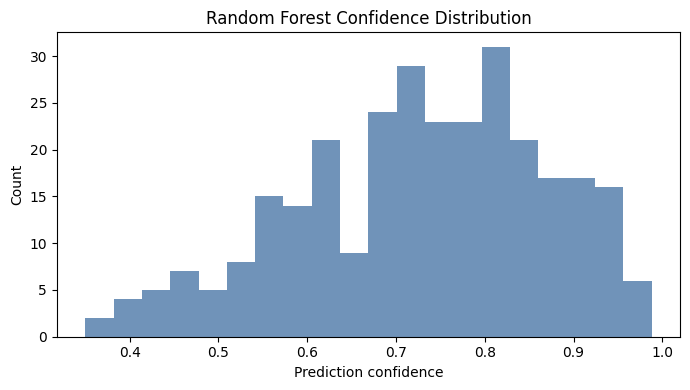

In [6]:
rf_config = RFConfig(image_size=64, pca_n_components=0.95, n_estimators=500, random_state=42, n_jobs=-1)
rf_output_dir = RESULTS_ROOT / 'random_forest_pca'
rf_data = prepare_rf_data(manifest, rf_config, output_dir=rf_output_dir)
rf_model = train_random_forest(rf_data, rf_config, rf_output_dir)
rf_predictions, rf_metrics, rf_report = evaluate_random_forest_and_save(rf_model, rf_data, rf_output_dir, split_name='test', prefix='random_forest_test')
display(pd.DataFrame([rf_metrics]).drop(columns=['confusion_matrix', 'classification_report']))
display(rf_report)
plot_confusion_matrix(rf_metrics, CLASS_NAMES, FIGURES_ROOT / 'rf_confusion_matrix.png')
plot_prediction_examples(rf_predictions, samples=6, correct=False, output_path=FIGURES_ROOT / 'rf_misclassified.png')
plot_prediction_examples(rf_predictions, samples=6, correct=True, output_path=FIGURES_ROOT / 'rf_correct.png')
plot_confidence_histogram(rf_predictions, 'Random Forest Confidence Distribution', FIGURES_ROOT / 'rf_confidence_histogram.png')

## 2. Baseline CNN

[baseline_cnn] epoch 1/20 train_loss=0.8153 train_acc=0.6135 val_loss=2.1005 val_acc=0.3367 val_macro_f1=0.1679
[baseline_cnn] new best checkpoint saved
[baseline_cnn] epoch 2/20 train_loss=0.6300 train_acc=0.6707 val_loss=1.2305 val_acc=0.4411 val_macro_f1=0.3598
[baseline_cnn] new best checkpoint saved
[baseline_cnn] epoch 3/20 train_loss=0.5529 train_acc=0.7178 val_loss=0.6034 val_acc=0.6397 val_macro_f1=0.6138
[baseline_cnn] new best checkpoint saved
[baseline_cnn] epoch 4/20 train_loss=0.5589 train_acc=0.7306 val_loss=1.2498 val_acc=0.4680 val_macro_f1=0.3989
[baseline_cnn] epoch 5/20 train_loss=0.4882 train_acc=0.7744 val_loss=0.4376 val_acc=0.7441 val_macro_f1=0.7215
[baseline_cnn] new best checkpoint saved
[baseline_cnn] epoch 6/20 train_loss=0.4415 train_acc=0.7987 val_loss=1.0342 val_acc=0.5825 val_macro_f1=0.5389
[baseline_cnn] epoch 7/20 train_loss=0.3327 train_acc=0.8653 val_loss=1.0916 val_acc=0.5825 val_macro_f1=0.5180
[baseline_cnn] epoch 8/20 train_loss=0.2454 train_ac

,epoch,train_loss,train_accuracy,train_macro_f1,val_loss,val_accuracy,val_macro_f1
15,16,0.110793,0.964310,0.964159,0.222994,0.898990,0.897238
16,17,0.069020,0.976431,0.976351,0.254510,0.885522,0.883656
17,18,0.140745,0.952862,0.952694,0.222866,0.902357,0.901921
18,19,0.101469,0.967677,0.967580,0.554135,0.777778,0.743154
19,20,0.105821,0.967677,0.967556,0.374101,0.794613,0.772723


,accuracy,precision_macro,recall_macro,f1_macro
0,0.767677,0.81529,0.765979,0.765195


,precision,recall,f1-score,support
actin,0.986111,0.710000,0.825581,100.000000
mitochondria,0.816901,0.597938,0.690476,97.000000
nucleus,0.642857,0.990000,0.779528,100.000000
accuracy,0.767677,0.767677,0.767677,0.767677
macro avg,0.815290,0.765979,0.765195,297.000000
weighted avg,0.815274,0.767677,0.765950,297.000000


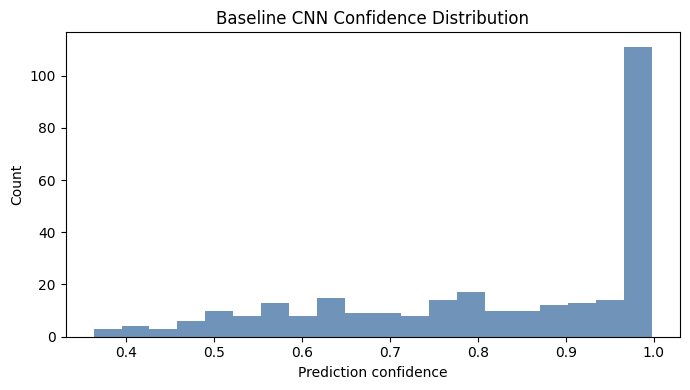

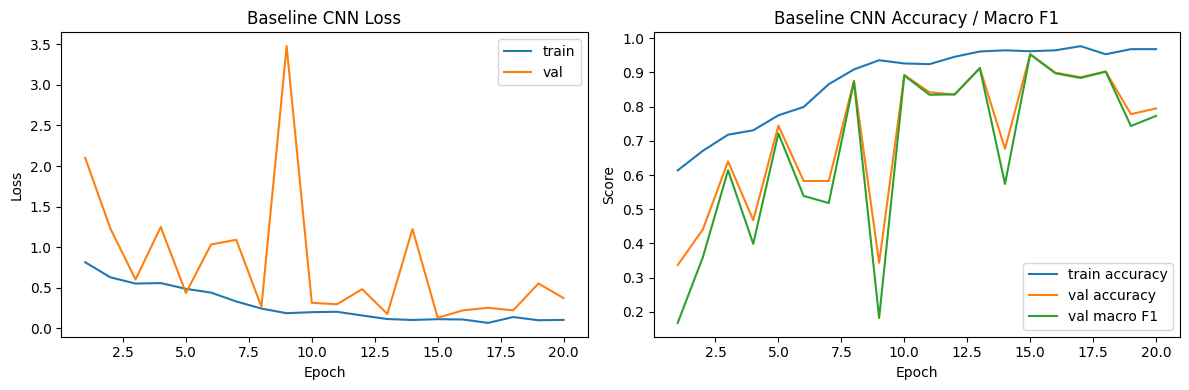

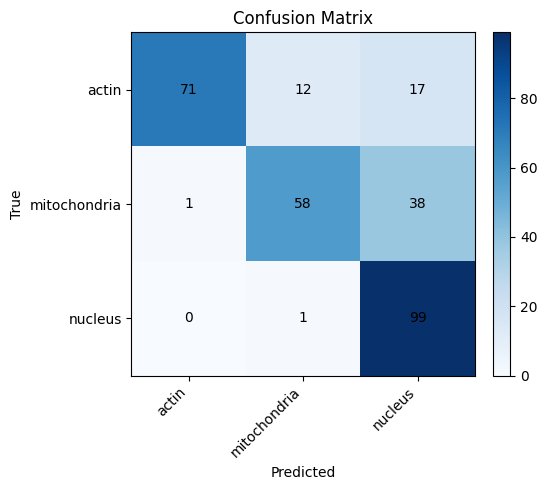

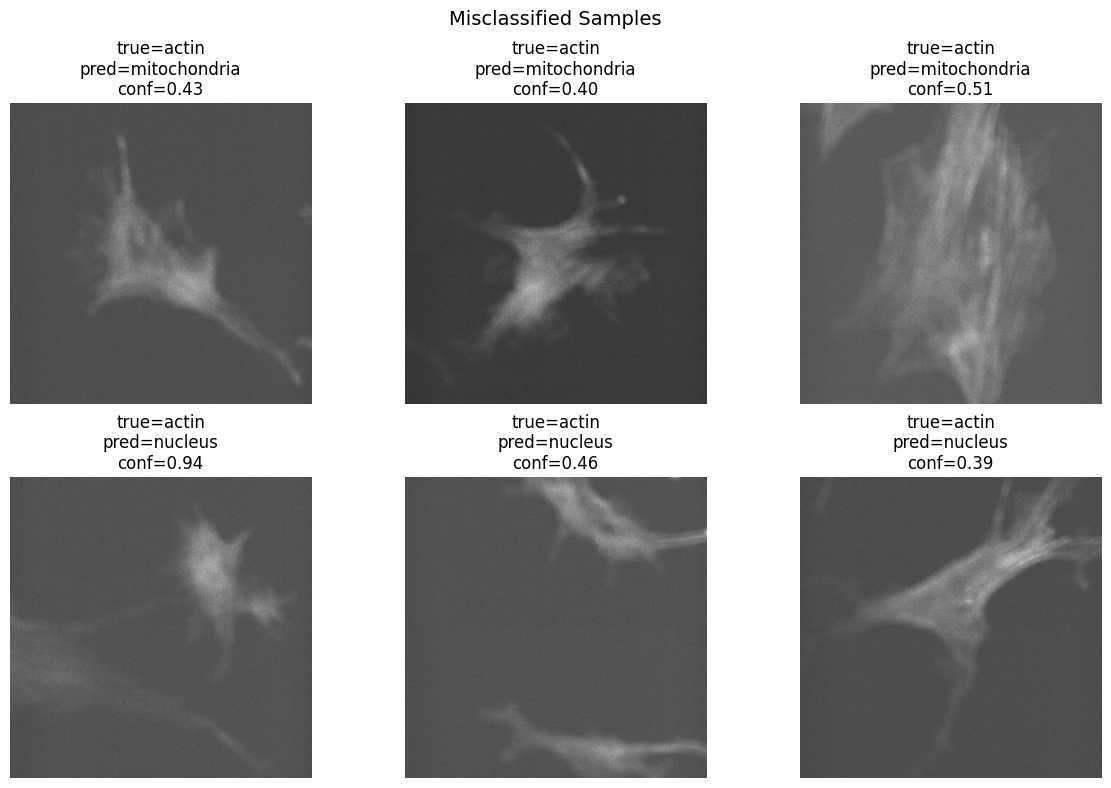

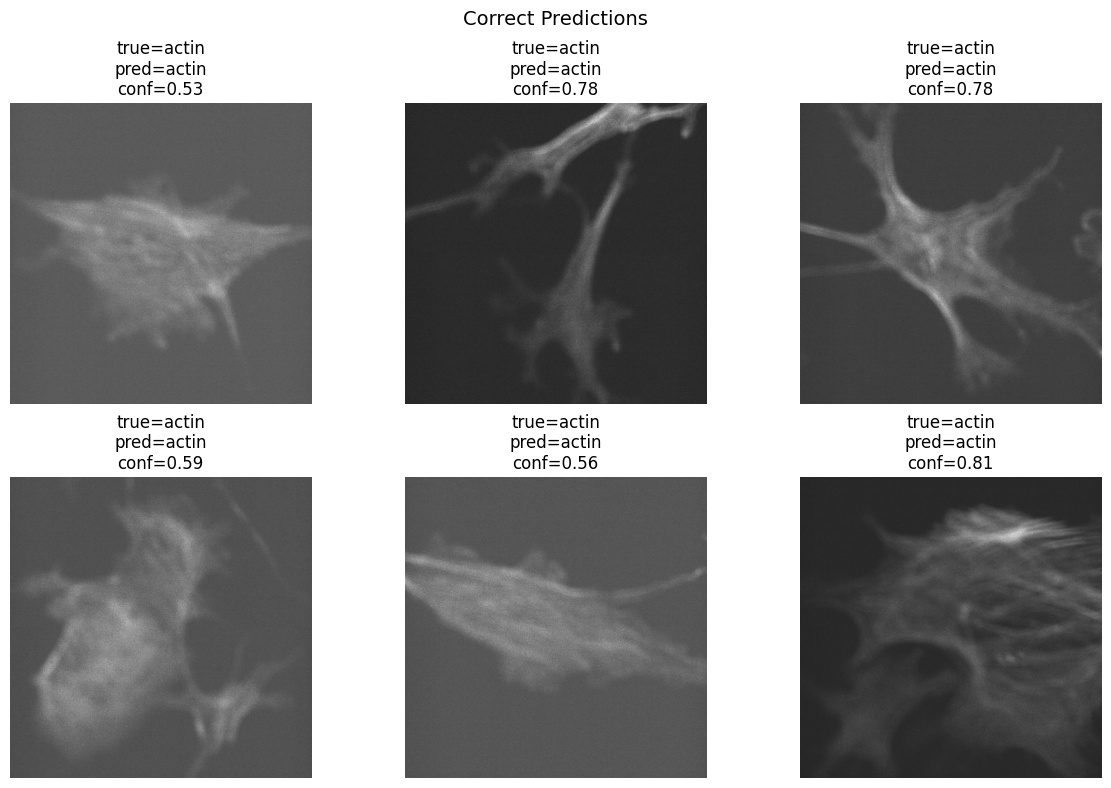

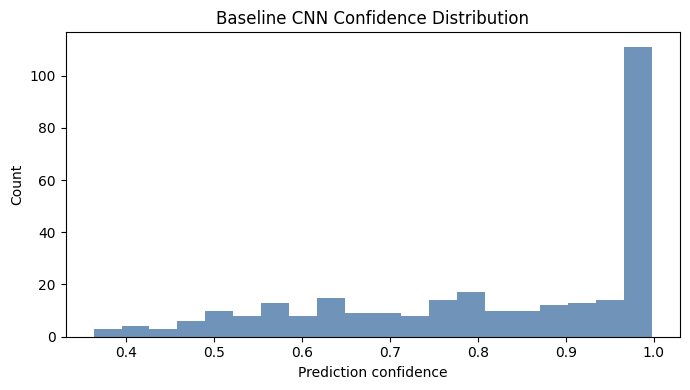

In [7]:
baseline_output_dir = RESULTS_ROOT / 'baseline_cnn'
baseline_loaders, baseline_datasets, _ = create_dataloaders(manifest, image_size=224, batch_size=32, num_workers=2, normalize_mode='simple')
baseline_config = TrainingConfig(model_name='baseline_cnn', image_size=224, batch_size=32, num_epochs=20, learning_rate=1e-3, early_stopping_patience=5, normalize_mode='simple', verbose=True)
baseline_model = build_model('baseline_cnn', num_classes=len(CLASS_NAMES), pretrained=False)
baseline_model, baseline_history = fit_model(baseline_model, baseline_loaders, baseline_config, baseline_output_dir, device=device, pretrained=False)
display(baseline_history.tail())
plot_training_history(baseline_history, 'Baseline CNN', FIGURES_ROOT / 'baseline_history.png')
baseline_predictions, baseline_metrics, baseline_report = evaluate_and_save(baseline_model, baseline_loaders['test'], baseline_output_dir, 'baseline_test', device=device)
display(pd.DataFrame([baseline_metrics]).drop(columns=['confusion_matrix', 'classification_report']))
display(baseline_report)
plot_confusion_matrix(baseline_metrics, CLASS_NAMES, FIGURES_ROOT / 'baseline_confusion_matrix.png')
plot_prediction_examples(baseline_predictions, samples=6, correct=False, output_path=FIGURES_ROOT / 'baseline_misclassified.png')
plot_prediction_examples(baseline_predictions, samples=6, correct=True, output_path=FIGURES_ROOT / 'baseline_correct.png')
plot_confidence_histogram(baseline_predictions, 'Baseline CNN Confidence Distribution', FIGURES_ROOT / 'baseline_confidence_histogram.png')

## 3. ResNet18

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 135MB/s]


[resnet18] epoch 1/20 train_loss=0.5812 train_acc=0.8061 val_loss=0.3388 val_acc=0.9461 val_macro_f1=0.9458
[resnet18] new best checkpoint saved
[resnet18] epoch 2/20 train_loss=0.2529 train_acc=0.9401 val_loss=0.1826 val_acc=0.9562 val_macro_f1=0.9560
[resnet18] new best checkpoint saved
[resnet18] epoch 3/20 train_loss=0.0442 train_acc=0.9879 val_loss=0.0400 val_acc=0.9832 val_macro_f1=0.9831
[resnet18] new best checkpoint saved
[resnet18] epoch 4/20 train_loss=0.0157 train_acc=0.9946 val_loss=0.0573 val_acc=0.9697 val_macro_f1=0.9694
[resnet18] epoch 5/20 train_loss=0.0074 train_acc=0.9960 val_loss=0.0015 val_acc=1.0000 val_macro_f1=1.0000
[resnet18] new best checkpoint saved
[resnet18] epoch 6/20 train_loss=0.0060 train_acc=0.9987 val_loss=0.0056 val_acc=0.9966 val_macro_f1=0.9966
[resnet18] epoch 7/20 train_loss=0.0052 train_acc=0.9987 val_loss=0.0012 val_acc=1.0000 val_macro_f1=1.0000
[resnet18] epoch 8/20 train_loss=0.0076 train_acc=0.9973 val_loss=0.0053 val_acc=0.9966 val_macr

,epoch,train_loss,train_accuracy,train_macro_f1,val_loss,val_accuracy,val_macro_f1
5,6,0.006027,0.998653,0.998646,0.005565,0.996633,0.996615
6,7,0.005175,0.998653,0.998646,0.001152,1.000000,1.000000
7,8,0.007607,0.997306,0.997292,0.005318,0.996633,0.996615
8,9,0.001574,1.000000,1.000000,0.000813,1.000000,1.000000
9,10,0.000899,1.000000,1.000000,0.000461,1.000000,1.000000


,accuracy,precision_macro,recall_macro,f1_macro
0,0.956229,0.958785,0.955533,0.955843


,precision,recall,f1-score,support
actin,0.899083,0.980000,0.937799,100.000000
mitochondria,0.977273,0.886598,0.929730,97.000000
nucleus,1.000000,1.000000,1.000000,100.000000
accuracy,0.956229,0.956229,0.956229,0.956229
macro avg,0.958785,0.955533,0.955843,297.000000
weighted avg,0.958598,0.956229,0.956107,297.000000


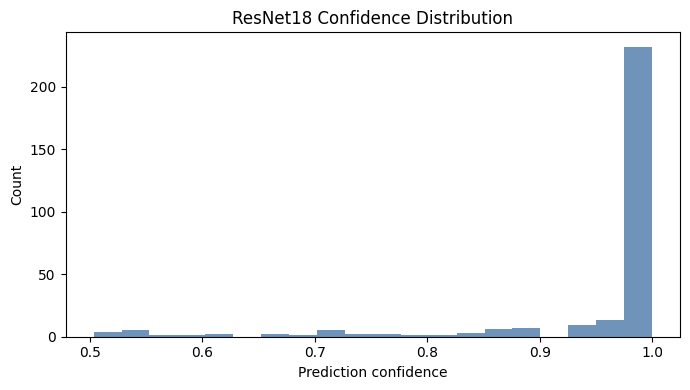

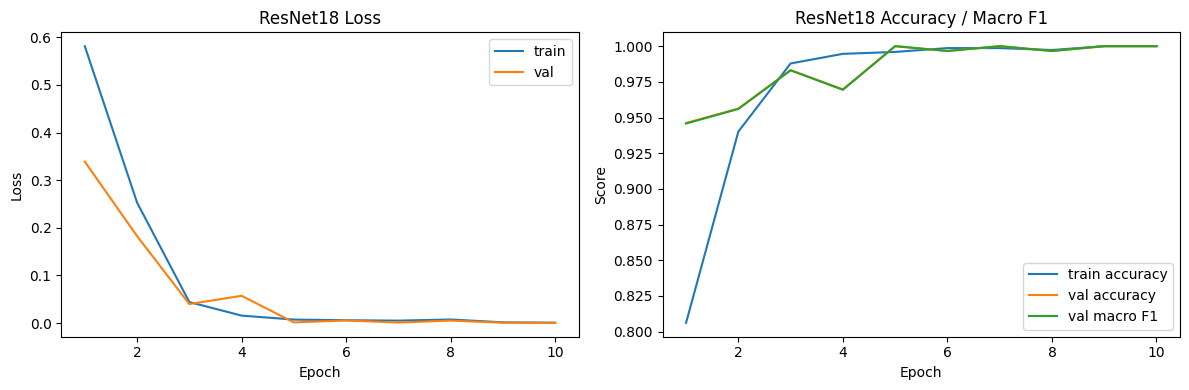

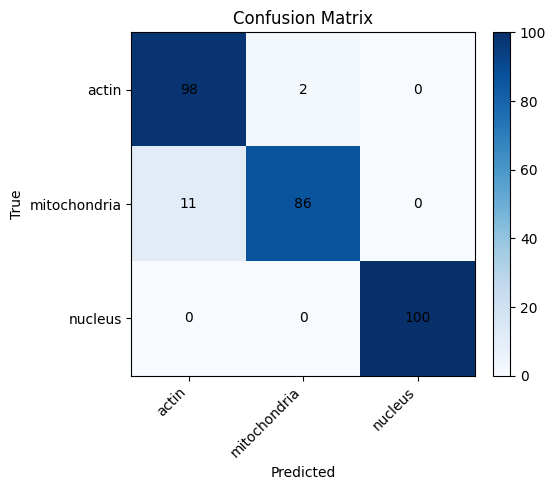

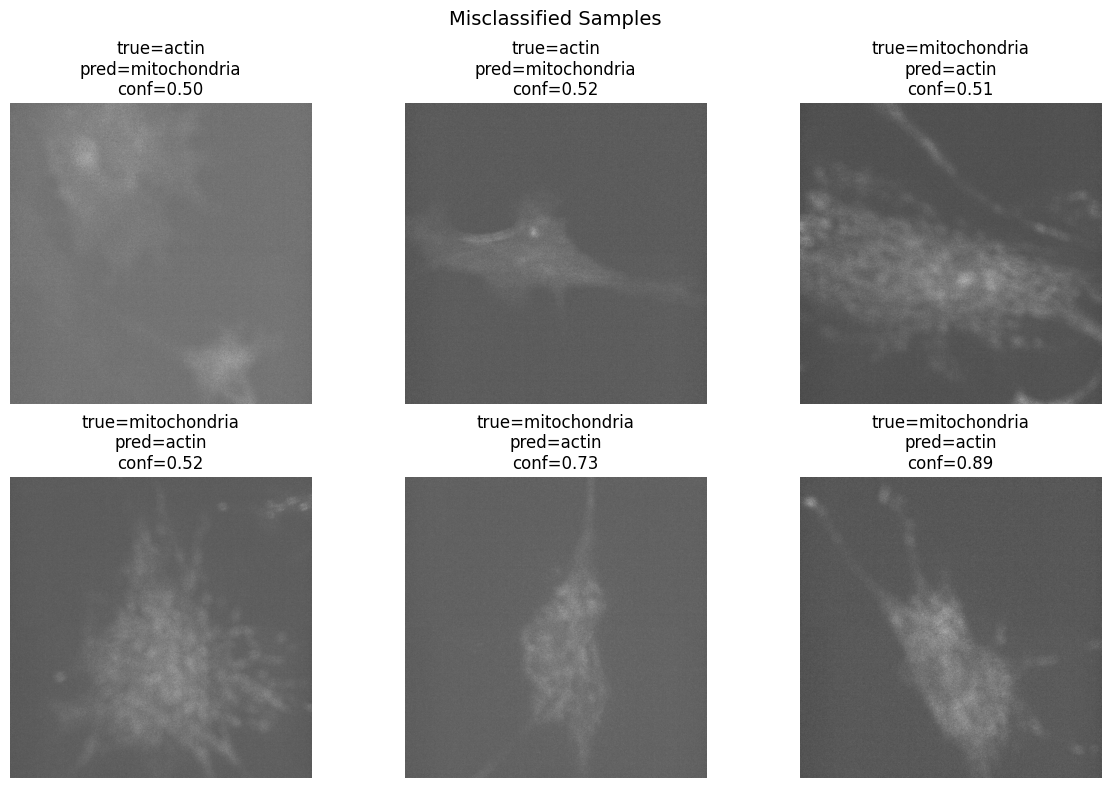

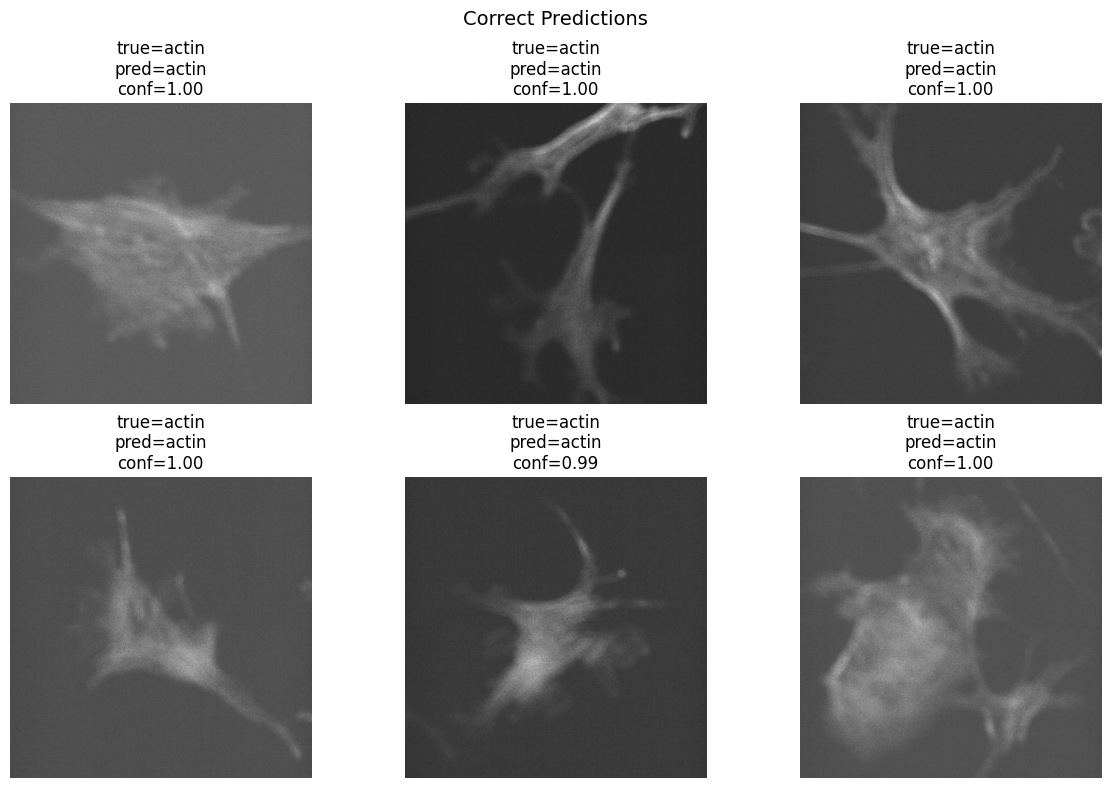

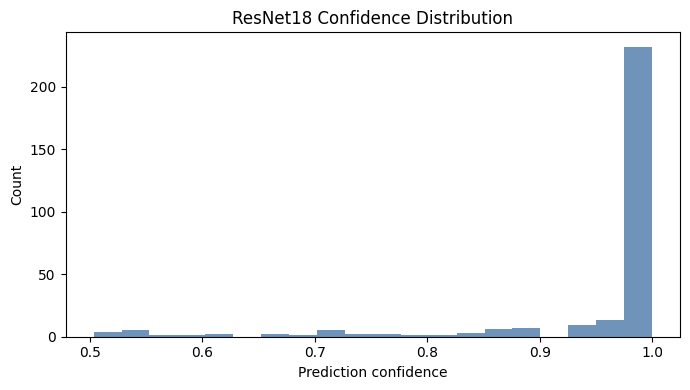

In [8]:
resnet_output_dir = RESULTS_ROOT / 'resnet18'
resnet_loaders, resnet_datasets, _ = create_dataloaders(manifest, image_size=224, batch_size=32, num_workers=2, normalize_mode='imagenet')
resnet_config = TrainingConfig(model_name='resnet18', image_size=224, batch_size=32, num_epochs=20, learning_rate=1e-3, fine_tune_learning_rate=1e-4, warmup_epochs=2, early_stopping_patience=5, normalize_mode='imagenet', verbose=True)
resnet_model = build_model('resnet18', num_classes=len(CLASS_NAMES), pretrained=True)
resnet_model, resnet_history = fit_model(resnet_model, resnet_loaders, resnet_config, resnet_output_dir, device=device, pretrained=True)
display(resnet_history.tail())
plot_training_history(resnet_history, 'ResNet18', FIGURES_ROOT / 'resnet18_history.png')
resnet_predictions, resnet_metrics, resnet_report = evaluate_and_save(resnet_model, resnet_loaders['test'], resnet_output_dir, 'resnet18_test', device=device)
display(pd.DataFrame([resnet_metrics]).drop(columns=['confusion_matrix', 'classification_report']))
display(resnet_report)
plot_confusion_matrix(resnet_metrics, CLASS_NAMES, FIGURES_ROOT / 'resnet18_confusion_matrix.png')
plot_prediction_examples(resnet_predictions, samples=6, correct=False, output_path=FIGURES_ROOT / 'resnet18_misclassified.png')
plot_prediction_examples(resnet_predictions, samples=6, correct=True, output_path=FIGURES_ROOT / 'resnet18_correct.png')
plot_confidence_histogram(resnet_predictions, 'ResNet18 Confidence Distribution', FIGURES_ROOT / 'resnet18_confidence_histogram.png')

## 4. Final Comparison

,model,accuracy,precision_macro,recall_macro,f1_macro
0,random_forest_pca,0.959596,0.959363,0.959485,0.959279
1,baseline_cnn,0.767677,0.815290,0.765979,0.765195
2,resnet18,0.956229,0.958785,0.955533,0.955843


,model,feature_style,spatial_learning,expected_strength
0,random_forest_pca,flattened pixels + PCA,no,classical baseline
1,baseline_cnn,learned convolutional features,yes,moderate deep-learning baseline
2,resnet18,pretrained deep hierarchical features,yes,strongest expected model


Training notebook complete. Run the presentation materials notebook next.


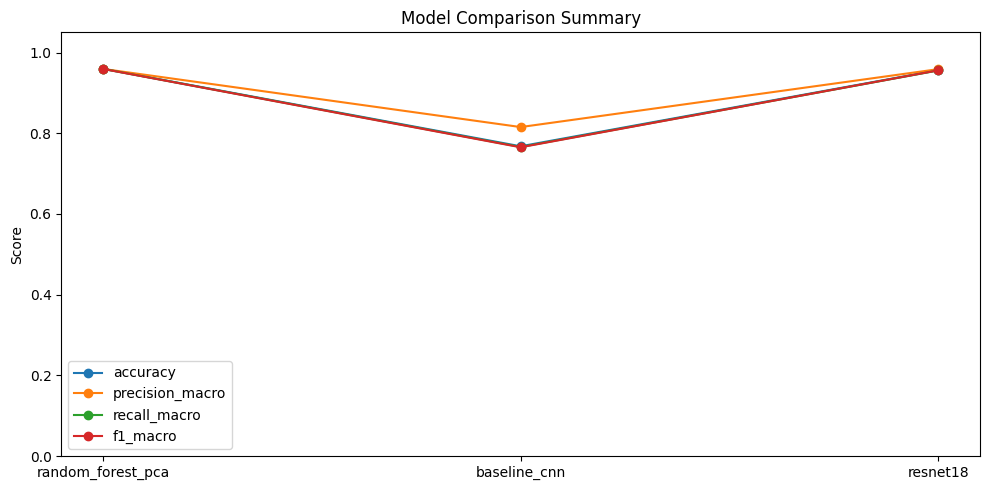

In [9]:
comparison = compare_model_metrics({
    'random_forest_pca': rf_metrics,
    'baseline_cnn': baseline_metrics,
    'resnet18': resnet_metrics,
})
comparison = comparison.set_index('model').loc[['random_forest_pca', 'baseline_cnn', 'resnet18']].reset_index()
comparison.to_csv(RESULTS_ROOT / 'model_comparison.csv', index=False)
display(comparison)
plot_model_comparison_chart(comparison, FIGURES_ROOT / 'model_comparison_chart.png')
richness = build_model_richness_table()
richness.to_csv(RESULTS_ROOT / 'model_richness_table.csv', index=False)
display(richness)
print('Training notebook complete. Run the presentation materials notebook next.')